# Análisis de textos

---

El *Procesamiento de Lenguaje Natural (NLP)* es una rama de la inteligencia artificial que permite a las computadoras entender, interpretar y generar lenguaje humano. Su objetivo es transformar textos o discursos en datos que una máquina pueda analizar, facilitando tareas como traducción automática, chatbots, análisis de sentimientos o motores de búsqueda. 📖🤖


##  Vectorización de textos

---

La *vectorización de textos* es el proceso de transformar palabras o frases en representaciones numéricas que las computadoras puedan procesar. 📊 En lugar de trabajar con texto plano, lo convertimos en vectores que permiten a los algoritmos de machine learning analizar, comparar y encontrar patrones en el lenguaje. ✨


In [1]:
#!pip install wordcloud spacy

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import spacy


In [25]:
#spacy.cli.download("es_core_news_sm")
nlp = spacy.load("es_core_news_sm")

In [26]:
sns.set_style('whitegrid')
sns.set_palette('viridis')

<center>
  <img src="https://i5.walmartimages.com.mx/gr/images/product-images/img_large/00360054263068L.jpg" alt="Regresion Descenso de Gradiente" style="max-width:50%; height:auto;"  width="30%">
</center>

In [27]:
opiniones=pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/16-ds-analisis-textos/opiniones_garnier.csv")
opiniones

,Comentario,Label
0,"Excelente producto, dejó mi piel luminosa y fr...",positiva
1,"Me encanta el aroma cítrico, es muy agradable",positiva
2,Funciona perfecto para limpiar suavemente,positiva
3,Noté mejoras rápidas en mis manchas,positiva
4,Mi piel se siente más uniforme,positiva
5,Gran relación calidad y precio,positiva
6,Absorbe rápido y no deja residuos,positiva
7,Ideal para usar diariamente,positiva
8,La vitamina C deja sensación refrescante,positiva
9,Mejoró mucho el aspecto de mi rostro,positiva


In [28]:
opiniones.shape, opiniones.Label.value_counts()

((60, 2),
 Label
 positiva    35
 negativa    25
 Name: count, dtype: int64)

In [29]:
# Longitud de comentarios y distribución
opiniones["len"] = opiniones["Comentario"].str.len()
opiniones["n_words"] = opiniones["Comentario"].apply(lambda x: len(x.split()))
opiniones.groupby("Label")["len"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
negativa,25.0,27.12,5.246586,21.0,23.0,26.0,30.0,45.0
positiva,35.0,31.80,6.072116,21.0,28.0,31.0,35.0,50.0


In [30]:
#Cantidad de palabras
opiniones.groupby("Label")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
negativa,25.0,4.760000,1.051982,2.0,4.0,5.0,5.0,8.0
positiva,35.0,5.314286,1.300937,2.0,5.0,5.0,6.0,8.0


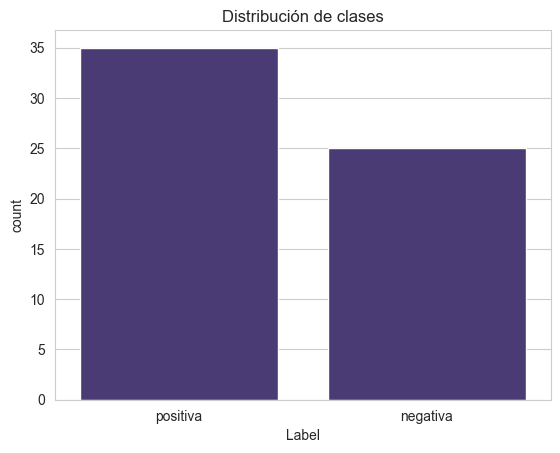

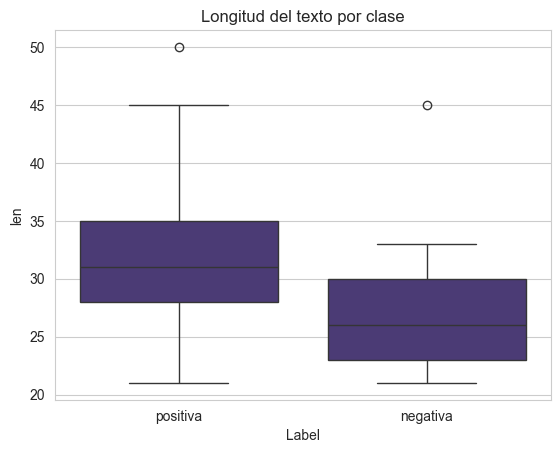

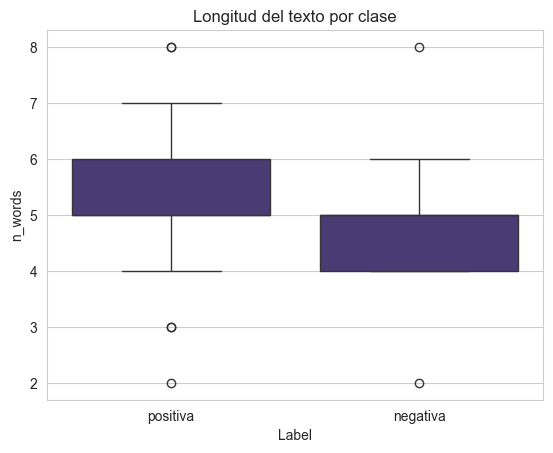

In [31]:


sns.countplot(data=opiniones, x="Label", order=["positiva","negativa"])
plt.title("Distribución de clases")
plt.show()

sns.boxplot(data=opiniones, x="Label", y="len", order=["positiva","negativa"])
plt.title("Longitud del texto por clase")
plt.show()

sns.boxplot(data=opiniones, x="Label", y="n_words", order=["positiva","negativa"])
plt.title("Longitud del texto por clase")
plt.show()

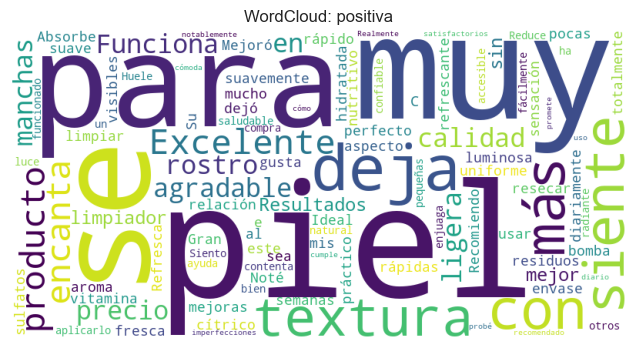

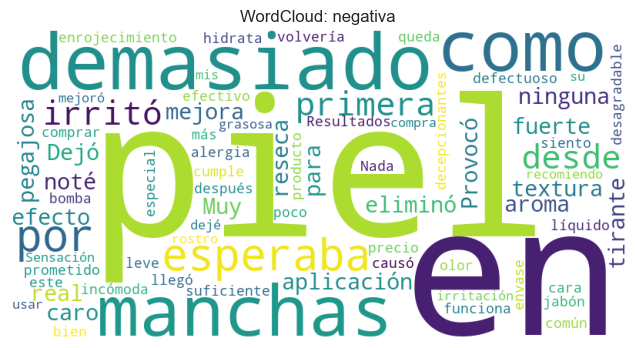

In [32]:
stop_es = set(STOPWORDS) | {"de","la","el","los","las","que","y","mi","me","lo","es"}

def nubes_por_clase(df, label):
    texto = " ".join(df.loc[df.Label==label, "Comentario"].astype(str))
    wc = WordCloud(width=800, height=400, stopwords=stop_es, background_color="white").generate(texto)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"WordCloud: {label}"); plt.show()

for lab in ["positiva","negativa"]:
    nubes_por_clase(opiniones, lab)

In [33]:
nlp = spacy.load("es_core_news_sm")

doc = nlp("Los estudiantes corriendo aprendieron rápidamente")
print([token.lemma_ for token in doc])

['el', 'estudiante', 'correr', 'aprender', 'rápidamente']


In [34]:
def lematizar(texto):
    doc = nlp(texto.lower())
    # quitamos puntuación, espacios y stopwords del modelo
    lemmas = [t.lemma_ for t in doc if not (t.is_punct or t.is_space or t.is_stop)]
    return " ".join(lemmas)

opiniones["Comentario_lem"] = opiniones["Comentario"].astype(str).apply(lematizar)
opiniones[["Comentario","Comentario_lem"]].head()

,Comentario,Comentario_lem
0,"Excelente producto, dejó mi piel luminosa y fr...",excelente producto piel luminoso fresco
1,"Me encanta el aroma cítrico, es muy agradable",encantar aroma cítrico agradable
2,Funciona perfecto para limpiar suavemente,funcionar perfecto limpiar suavemente
3,Noté mejoras rápidas en mis manchas,noté mejora rápido mancha
4,Mi piel se siente más uniforme,piel sentir uniforme


In [39]:
cv = CountVectorizer(ngram_range=(1,2), min_df=1)
X_bow = cv.fit_transform(opiniones["Comentario_lem"])
y = opiniones["Label"].apply(lambda x: int(x=='positiva'))

cv.get_feature_names_out()[:20], X_bow.shape

(array(['absorbe', 'absorbe rápido', 'accesible', 'accesible calidad',
        'agradable', 'alergia', 'alergia leve', 'aplicación', 'aplicar',
        'aplicar él', 'aroma', 'aroma cítrico', 'aroma fuerte', 'aspecto',
        'aspecto rostro', 'ayudar', 'ayudar mancha', 'bomba',
        'bomba funcionar', 'bomba práctico'], dtype=object),
 (60, 212))

In [40]:
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1)
X_tfidf = tfidf.fit_transform(opiniones["Comentario_lem"])
X_tfidf.shape

(60, 212)

In [44]:
# 
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.5, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=200, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        13
           1      0.567     1.000     0.723        17

    accuracy                          0.567        30
   macro avg      0.283     0.500     0.362        30
weighted avg      0.321     0.567     0.410        30

[[ 0 13]
 [ 0 17]]


c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [43]:
# Cambia X_bow por X_tfidf si quieres usar TF-IDF
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.5, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=200, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        13
           1      0.567     1.000     0.723        17

    accuracy                          0.567        30
   macro avg      0.283     0.500     0.362        30
weighted avg      0.321     0.567     0.410        30

[[ 0 13]
 [ 0 17]]


c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr